# Определение стоимости автомобилей

Сервис по продаже автомобилей с пробегом «Не бит, не крашен» разрабатывает приложение для привлечения новых клиентов. В нём можно быстро узнать рыночную стоимость своего автомобиля. В вашем распоряжении исторические данные: технические характеристики, комплектации и цены автомобилей. Вам нужно построить модель для определения стоимости. 

Заказчику важны:

- качество предсказания;
- скорость предсказания;
- время обучения.

## Подготовка данных

In [1]:
!pip install lightgbm

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from tqdm import tqdm
from lightgbm import LGBMRegressor
import lightgbm as lgb

In [3]:
# Выгружаем наш датасет и первично его оцениваем
df = pd.read_csv('autos.csv')
df.head()

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,RegistrationMonth,FuelType,Brand,Repaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
0,2016-03-24 11:52:17,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,2016-03-24 00:00:00,0,70435,2016-04-07 03:16:57
1,2016-03-24 10:58:45,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,2016-03-24 00:00:00,0,66954,2016-04-07 01:46:50
2,2016-03-14 12:52:21,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,2016-03-14 00:00:00,0,90480,2016-04-05 12:47:46
3,2016-03-17 16:54:04,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,2016-03-17 00:00:00,0,91074,2016-03-17 17:40:17
4,2016-03-31 17:25:20,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,2016-03-31 00:00:00,0,60437,2016-04-06 10:17:21


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354369 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   DateCrawled        354369 non-null  object
 1   Price              354369 non-null  int64 
 2   VehicleType        316879 non-null  object
 3   RegistrationYear   354369 non-null  int64 
 4   Gearbox            334536 non-null  object
 5   Power              354369 non-null  int64 
 6   Model              334664 non-null  object
 7   Kilometer          354369 non-null  int64 
 8   RegistrationMonth  354369 non-null  int64 
 9   FuelType           321474 non-null  object
 10  Brand              354369 non-null  object
 11  Repaired           283215 non-null  object
 12  DateCreated        354369 non-null  object
 13  NumberOfPictures   354369 non-null  int64 
 14  PostalCode         354369 non-null  int64 
 15  LastSeen           354369 non-null  object
dtypes: int64(7), object(

-----------------------------------------------------------------------------
Видим, что в датасете много пропусков


Пропуски есть в столбцах: 
* VehicleType - тип автомобильного кузова,
* Gearbox - тип коробки передач,
* Model - модель автомобиля,
* FuelType - тип топлива,
* Repaired - была машина в ремонте или нет

Все они текстовые, поэтому мы можем заменить все пропуски на "unknown", чтобы не удалять эти строки из датасета и не терять данные.

P.S. Мы не заносим пустые значения в "other", т.к. это может помешать модели правильно обучаться. В "другие" обычно попадают редкие автомобили, для которых может быть нестабильное ценообразование, а в "неизвестно" могут быть любые машины, для которых пользователь не указал модель.

In [5]:
df = df.fillna('unknown')

### Проверим датасет на дубликаты и выбросы

In [6]:
df['VehicleType'].unique()

array(['unknown', 'coupe', 'suv', 'small', 'sedan', 'convertible', 'bus',
       'wagon', 'other'], dtype=object)

In [7]:
df['Gearbox'].unique()

array(['manual', 'auto', 'unknown'], dtype=object)

In [8]:
df['FuelType'].unique()

array(['petrol', 'gasoline', 'unknown', 'lpg', 'other', 'hybrid', 'cng',
       'electric'], dtype=object)

In [9]:
df['Brand'].unique()

array(['volkswagen', 'audi', 'jeep', 'skoda', 'bmw', 'peugeot', 'ford',
       'mazda', 'nissan', 'renault', 'mercedes_benz', 'opel', 'seat',
       'citroen', 'honda', 'fiat', 'mini', 'smart', 'hyundai',
       'sonstige_autos', 'alfa_romeo', 'subaru', 'volvo', 'mitsubishi',
       'kia', 'suzuki', 'lancia', 'toyota', 'chevrolet', 'dacia',
       'daihatsu', 'trabant', 'saab', 'chrysler', 'jaguar', 'daewoo',
       'porsche', 'rover', 'land_rover', 'lada'], dtype=object)

In [10]:
df['Repaired'].unique()

array(['unknown', 'yes', 'no'], dtype=object)

In [11]:
df.describe()

,Price,RegistrationYear,Power,Kilometer,RegistrationMonth,NumberOfPictures,PostalCode
count,354369.000000,354369.000000,354369.000000,354369.000000,354369.000000,354369.0,354369.000000
mean,4416.656776,2004.234448,110.094337,128211.172535,5.714645,0.0,50508.689087
std,4514.158514,90.227958,189.850405,37905.341530,3.726421,0.0,25783.096248
min,0.000000,1000.000000,0.000000,5000.000000,0.000000,0.0,1067.000000
25%,1050.000000,1999.000000,69.000000,125000.000000,3.000000,0.0,30165.000000
50%,2700.000000,2003.000000,105.000000,150000.000000,6.000000,0.0,49413.000000
75%,6400.000000,2008.000000,143.000000,150000.000000,9.000000,0.0,71083.000000
max,20000.000000,9999.000000,20000.000000,150000.000000,12.000000,0.0,99998.000000


--------------------------------------------------
Неявные дубликаты не были найдены, но зато было обнаружено, что столбец с количеством фото в объявлении содержит исключительно нули, поэтому мы его удалим. А также найдены абсурдные значения (аномалии) и выбросы:
* В столбце "Price" много значения цены 0, а также просто очень низких цен. Это исказит данные и испортит модель
* В столбце "Power" есть как аномально большие значения, так и аномально маленькие (0). Срежем их с обеих сторон
* В столбце RegistrationMonth много значений месяца 0, но такого месяца нет. Так как этот признак не сильно важный, просто заменим 0 на 1
* RegistrationYear также дает аномальные значения (от 1000 года до 9999 года). Срежем их с двух сторон.

In [12]:
df = df.drop(['NumberOfPictures'],axis=1)

<Axes: >

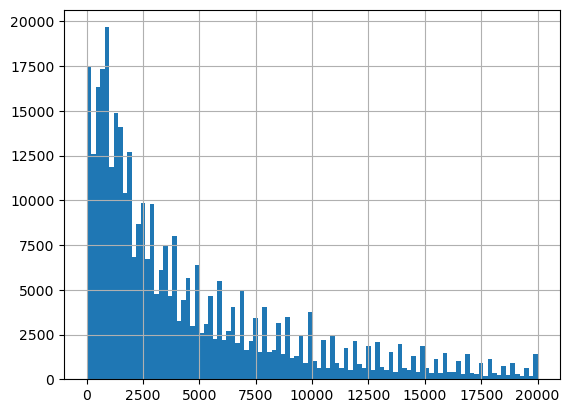

In [13]:
df['Price'].hist(bins=100)

In [14]:
print(df['Price'].quantile([0.01, 0.05, 0.1]))

0.01      0.0
0.05    200.0
0.10    499.0
Name: Price, dtype: float64


<Axes: >

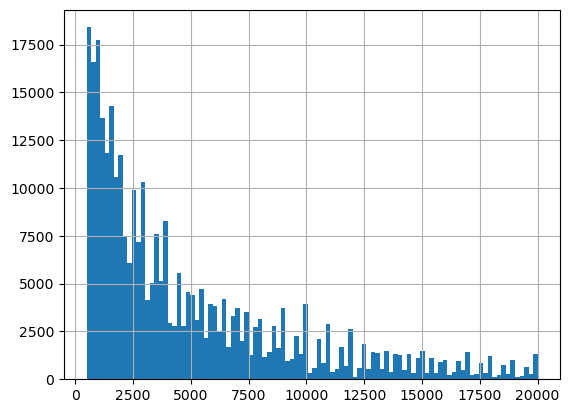

In [15]:
df = df.query('Price>=500')
df['Price'].hist(bins=100)

In [16]:
# 1. Удаляем явный бред в мощности (например, меньше 40 и больше 1000 л.с.)
df = df.query('40 <= Power <= 1000')
# 2. Месяц можно заменить на 1 (январь), чтобы не было нуля
df.loc[df['RegistrationMonth'] == 0, 'RegistrationMonth'] = 1
# 3. Года оставляем только адекватные (дата выгрузки выборки 2016 г)
df = df.query('1960 <= RegistrationYear <= 2016')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 278308 entries, 1 to 354368
Data columns (total 15 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   DateCrawled        278308 non-null  object
 1   Price              278308 non-null  int64 
 2   VehicleType        278308 non-null  object
 3   RegistrationYear   278308 non-null  int64 
 4   Gearbox            278308 non-null  object
 5   Power              278308 non-null  int64 
 6   Model              278308 non-null  object
 7   Kilometer          278308 non-null  int64 
 8   RegistrationMonth  278308 non-null  int64 
 9   FuelType           278308 non-null  object
 10  Brand              278308 non-null  object
 11  Repaired           278308 non-null  object
 12  DateCreated        278308 non-null  object
 13  PostalCode         278308 non-null  int64 
 14  LastSeen           278308 non-null  object
dtypes: int64(6), object(9)
memory usage: 34.0+ MB


In [17]:
df = df.drop_duplicates()

In [18]:
df.describe()

,Price,RegistrationYear,Power,Kilometer,RegistrationMonth,PostalCode
count,278304.000000,278304.000000,278304.000000,278304.000000,278304.00000,278304.000000
mean,5135.785102,2003.159606,123.499324,127916.271415,6.12320,51460.566435
std,4607.581161,6.241872,54.392422,36728.988626,3.46853,25720.883712
min,500.000000,1960.000000,40.000000,5000.000000,1.00000,1067.000000
25%,1550.000000,1999.000000,82.000000,125000.000000,3.00000,31139.000000
50%,3500.000000,2003.000000,116.000000,150000.000000,6.00000,50735.000000
75%,7400.000000,2007.000000,150.000000,150000.000000,9.00000,72202.000000
max,20000.000000,2016.000000,1000.000000,150000.000000,12.00000,99998.000000


----------------------------------
Ну вот, теперь мы получили адекватные данные. Можно переходить к следующему шагу и завершать предобработку

## Обучение моделей

### Подготовка выборок для обучения моделей

В признаки помимо нашего целевого признака мы не будем включать также и DateCrawled, DateCreated, PostalCode, LastSeen т.к. они не несут полезной информации и только запутают нашу модель

In [19]:
df = df.reset_index(drop=True)
features = df.drop(['DateCrawled','Price','DateCreated','PostalCode','LastSeen'],axis=1)
target = df['Price']

In [20]:
features_train,features_vt,target_train,target_vt = train_test_split(
    features,target,test_size = 0.4,random_state = 12345)
features_valid,features_test,target_valid,target_test = train_test_split(
    features_vt,target_vt,test_size = 0.5, random_state = 12345)
display(features_valid.head())
display(target_valid.to_frame().head())

,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,RegistrationMonth,FuelType,Brand,Repaired
274571,convertible,2008,auto,306,3er,150000,5,petrol,bmw,no
110810,bus,2007,auto,131,s_max,150000,3,gasoline,ford,no
253637,bus,2005,manual,75,caddy,150000,4,petrol,volkswagen,no
242082,small,2013,unknown,150,golf,80000,7,unknown,volkswagen,no
204199,bus,2007,manual,131,transporter,150000,2,gasoline,volkswagen,no


,Price
274571,19500
110810,7400
253637,5000
242082,14500
204199,14000


### Catboost 

In [21]:
%%time
model_cat = CatBoostRegressor(loss_function="RMSE", iterations=250, random_seed=42, early_stopping_rounds=50,depth=10)
cat_features = ['VehicleType','Gearbox','Model','FuelType','Brand','Repaired']
model_cat.fit(features_train,target_train,cat_features = cat_features,verbose=50)

Learning rate set to 0.283685
0:	learn: 3689.1831740	total: 496ms	remaining: 2m 3s
50:	learn: 1552.5539184	total: 15.8s	remaining: 1m 1s
100:	learn: 1458.3372958	total: 30.6s	remaining: 45.1s
150:	learn: 1401.1050889	total: 46s	remaining: 30.2s
200:	learn: 1358.0596409	total: 1m 1s	remaining: 15s
249:	learn: 1320.0692315	total: 1m 16s	remaining: 0us
CPU times: total: 7min 44s
Wall time: 1min 18s


CatBoostRegressor(depth=10, early_stopping_rounds=50, iterations=250, loss_function='RMSE', random_seed=42)

In [22]:
%%time
predict_cat = model_cat.predict(features_valid)

CPU times: total: 1.39 s
Wall time: 437 ms


In [23]:
print('RMSE модели: ', np.sqrt(mean_squared_error(target_valid,predict_cat)))

RMSE модели:  1526.1075357387263


### OHE преобразуем категориальные переменные для других моделей

In [24]:
# 1. Создаем энкодер (handle_unknown='ignore' спасет, если в тесте будет новая марка авто)
encoder = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)

# 2. Обучаем только на TRAIN
encoder.fit(features_train[cat_features])

features_train_ohe = encoder.transform(features_train[cat_features])
features_valid_ohe = encoder.transform(features_valid[cat_features])
features_test_ohe = encoder.transform(features_test[cat_features])
print(features_train_ohe.shape[1],features_valid_ohe.shape[1],features_test_ohe.shape[1])

307 307 307


### Лес решений

In [25]:
best_rmse = float('inf')
for est in tqdm(range(10,51,10)):
    for depth in range(5,13,2):
        model_forest = RandomForestRegressor(random_state = 12, n_estimators = est, max_depth = depth,n_jobs=-1)
        model_forest.fit(features_train_ohe,target_train)
        predict_forest = model_forest.predict(features_valid_ohe)
        forest_rmse = np.sqrt(mean_squared_error(target_valid,predict_forest))
        if forest_rmse<best_rmse:
            best_rmse = forest_rmse
            best_depth = depth
            best_est = est
print('Лучшее RMSE: {:.3f}, при количестве деревьев: {}, и глубине: {}'.format(best_rmse,best_est,best_depth))

100%|██████████| 5/5 [19:10<00:00, 230.11s/it]

Лучшее RMSE: 3786.991, при количестве деревьев: 50, и глубине: 11


### LightGBM

In [26]:
for col in cat_features:
    features_train[col] = features_train[col].astype('category')
    features_valid[col] = features_valid[col].astype('category')

In [27]:
%%time
model_lgbm = LGBMRegressor(
    n_estimators = 100,
    learning_rate = 0.1,
    max_depth = 10,
    random_state = 42)
model_lgbm.fit(features_train,target_train,
              eval_set=[(features_valid,target_valid)],
              eval_metric = 'rmse',
              callbacks=[lgb.early_stopping(stopping_rounds=50)] # ранняя остановка
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008263 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 641
[LightGBM] [Info] Number of data points in the train set: 166982, number of used features: 10
[LightGBM] [Info] Start training from score 5133.685511
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's rmse: 1592.12	valid_0's l2: 2.53486e+06
CPU times: total: 7.86 s
Wall time: 1.73 s


LGBMRegressor(max_depth=10, random_state=42)

In [28]:
%%time
predict_lgbm = model_lgbm.predict(features_valid)

CPU times: total: 1.17 s
Wall time: 158 ms


In [29]:
print('RMSE LightGBM: {:.3f}'.format(np.sqrt(mean_squared_error(target_valid, predict_lgbm))))

RMSE LightGBM: 1592.124


## Анализ моделей

In [30]:
columns = ['Модель','RMSE','Wall time','CPU time','Время предсказания']
info = [
    ['Catboost',1526.107,'1min 9s','7min 13s','272 ms'],
    ['Лес решений',3786.991,'19m 2s','-','-'],
    ['Light GBM',1592.124,'1.5 s','8.25 s','122 ms']
]
dif = pd.DataFrame(info,columns=columns).sort_values(by='RMSE',ascending=True)
dif

,Модель,RMSE,Wall time,CPU time,Время предсказания
0,Catboost,1526.107,1min 9s,7min 13s,272 ms
2,Light GBM,1592.124,1.5 s,8.25 s,122 ms
1,Лес решений,3786.991,19m 2s,-,-


--------------------------------
По результатам обучения трех моделей мы выяснили, что наилучшие модели для данной задачи - это модели, обучающиеся с применением градиентного бустинга. Они быстрее обучаются и дают более качественный результат. Catboost и Light GBM дали примерно одинаковые результаты, но у первого выше показатель метрики, а у второго сильно выше скорость. Время предсказания при этом практически не отличается. 

Для финального тестирования выбрана модель CatBoostRegressor. Несмотря на то, что LightGBM значительно превосходит её в скорости обучения, CatBoost показал наилучшее качество предсказания (RMSE: 1526). Разница в качестве является критичной для бизнеса, в то время как время обучения в 68 секунд остается в рамках комфортного диапазона.

---------------------------

## Проверка модели на тестовой выборке

In [31]:
predict_cat_test = model_cat.predict(features_test)
print('RMSE модели: ', np.sqrt(mean_squared_error(target_test,predict_cat_test)))

RMSE модели:  1523.1804776946194
